Dealing with missing data and cleaning the dataset to make it ready for GNN algorithms

In [162]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [163]:
protein_data = pd.read_csv('../AAA_Proteomics_STRING_filtered.csv')
print(protein_data.head(3))

   Genes  Sample 1   Sample 2  Sample 3  Sample 4  Sample 5  Sample 60  \
0  MAPK1  7.802514  10.202104  9.953741  9.398615  8.750083   8.618377   
1   F8A1       NaN   7.770043  8.416663  7.179153  9.049793        NaN   
2  SUGT1       NaN   9.787278  7.674279  8.868290  7.480898        NaN   

   Sample 6   Sample 7  Sample 8  ...  Sample 37  Sample 79  Sample 61  \
0  8.981996  10.487751  9.487393  ...        NaN        NaN        NaN   
1  7.979900   8.314826       NaN  ...        NaN        NaN        NaN   
2  8.244653   9.618045  8.504347  ...        NaN        NaN        NaN   

   Sample 66  Sample 31  Sample 52  Sample 76  Sample 83  Sample 87  Sample 90  
0        NaN        NaN        NaN        NaN        NaN        NaN        NaN  
1        NaN        NaN        NaN        NaN        NaN        NaN        NaN  
2        NaN        NaN        NaN        NaN        NaN        NaN        NaN  

[3 rows x 86 columns]


In [164]:
assert protein_data['Genes'].duplicated().sum() == 0, "Duplicate genes found!"

In [165]:
protein_data.shape

(1766, 86)

Separate features from metadata

In [ ]:
gene_symbols = protein_data['Genes']
expression_matrix = protein_data.drop(columns='Genes') 

In [167]:
print(protein_data.head(10))

   Genes  Sample 1   Sample 2   Sample 3   Sample 4   Sample 5  Sample 60  \
0  MAPK1  7.802514  10.202104   9.953741   9.398615   8.750083   8.618377   
1   F8A1       NaN   7.770043   8.416663   7.179153   9.049793        NaN   
2  SUGT1       NaN   9.787278   7.674279   8.868290   7.480898        NaN   
3   RBX1       NaN   9.263706   9.463213   8.738964   9.040746   8.210388   
4   PEPD       NaN   8.238970   7.633213   8.197812   7.967809   7.550712   
5  EEF1G  8.658194  10.967775  12.913032  10.452812  12.098784  10.537974   
6   VTA1       NaN   8.468172   9.322748   8.312569  10.084401   8.747556   
7   LSM5  6.610382   8.416187  10.032527   7.744039  11.051090   8.795145   
8  PFDN1       NaN   9.448796  10.136892   8.829931  10.266574   8.939640   
9  PSMD5  7.072156   8.612993   9.984705   8.199515  10.078999   9.307480   

    Sample 6   Sample 7   Sample 8  ...  Sample 37  Sample 79  Sample 61  \
0   8.981996  10.487751   9.487393  ...        NaN        NaN        NaN   


Inspect missing data at the expression_matrix level

In [168]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer

print("=== Global Missingness ===")
print(f"Total missing values: {expression_matrix.isnull().sum().sum()}")
print(f"Percentage missing: {expression_matrix.isnull().mean().mean()*100:.2f}%")

=== Global Missingness ===
Total missing values: 37820
Percentage missing: 25.19%


Protein-level missingness


Top 5 proteins with most missing data:
1085    0.988235
1711    0.988235
1689    0.988235
1701    0.988235
1668    0.988235
1338    0.988235
921     0.988235
690     0.988235
153     0.976471
1739    0.976471
1577    0.976471
1435    0.976471
1656    0.964706
1356    0.964706
1681    0.964706
1505    0.964706
1585    0.964706
1141    0.964706
1562    0.964706
1748    0.964706
206     0.952941
1763    0.952941
1339    0.952941
1574    0.952941
1477    0.952941
1256    0.952941
1551    0.952941
1471    0.941176
1717    0.941176
1676    0.941176
1752    0.941176
1221    0.929412
1660    0.929412
1348    0.929412
345     0.929412
1372    0.929412
1737    0.929412
1738    0.929412
51      0.917647
1715    0.917647
1651    0.917647
1639    0.917647
1625    0.917647
1590    0.917647
503     0.917647
1708    0.917647
776     0.917647
1695    0.905882
1710    0.905882
1304    0.905882
dtype: float64


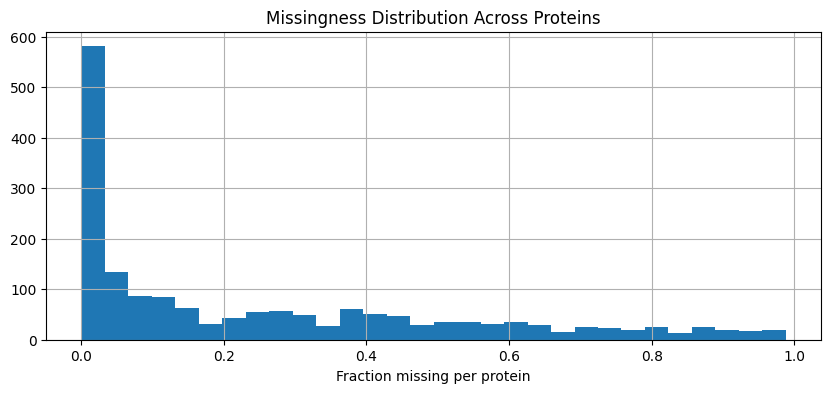

In [169]:
protein_missingness = protein_data.iloc[:, 1:].isnull().mean(axis=1)
print("\nTop 5 proteins with most missing data:")
print(protein_missingness.sort_values(ascending=False).head(50))

# Visualize
plt.figure(figsize=(10,4))
protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Proteins")
plt.xlabel("Fraction missing per protein")
plt.show()

In [ ]:
import pandas as pd

protein_missingness = protein_data.iloc[:, 1:].isnull().mean(axis=1) * 100

missingness_df = pd.DataFrame({
    'protein': protein_data.iloc[:, 0],  
    'missingness_percentage': protein_missingness
})

missingness_df.to_csv('protein_missingness.csv', index=False)

print(missingness_df.head())


  protein  missingness_percentage
0   MAPK1               20.000000
1    F8A1               52.941176
2   SUGT1               36.470588
3    RBX1               30.588235
4    PEPD               25.882353


Patient-level missingness 


Top 5 patients with most missing data:
Sample 46    0.616082
Sample 52    0.580974
Sample 57    0.548131
Sample 90    0.522650
Sample 67    0.507928
dtype: float64


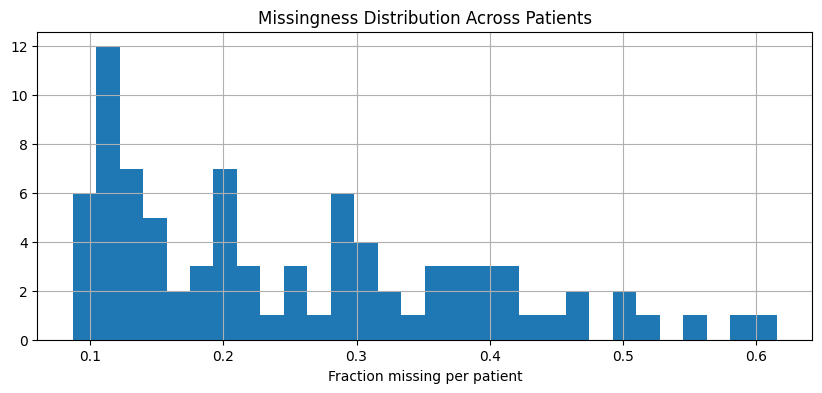

In [ ]:
patient_missingness = protein_data.iloc[:, 1:].isnull().mean(axis=0)
print("\nTop 5 patients with most missing data:")
print(patient_missingness.sort_values(ascending=False).head())

plt.figure(figsize=(10,4))
patient_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Patients")
plt.xlabel("Fraction missing per patient")
plt.show()

In [ ]:
patient_missingness = protein_data.iloc[:, 1:].isnull().mean(axis=0) * 100

missingness_sample_df = pd.DataFrame({
    'sample': protein_data.columns[1:],
    'missingness_percentage': patient_missingness
})

missingness_sample_df.to_csv('sample_missingness.csv', index=False)

print("\nTop 5 samples with most missing data:")
print(missingness_sample_df.sort_values(by='missingness_percentage', ascending=False).head())



Top 5 samples with most missing data:
              sample  missingness_percentage
Sample 46  Sample 46               61.608154
Sample 52  Sample 52               58.097395
Sample 57  Sample 57               54.813137
Sample 90  Sample 90               52.265006
Sample 67  Sample 67               50.792752


Iterative filtering approach

Patients first since:
    Patients with high missingness can artificially inflate protein missingness. Clinical samples (especially outliers) often reflect technical issues (e.g., poor sample quality).

In [ ]:
patient_missingness = protein_data.iloc[:,1:].isnull().mean(axis=0)

# Dynamic threshold - keep at least 70 patients (adjust as needed)
target_keep_patients = 75 
patient_threshold = np.percentile(patient_missingness, 100*(target_keep_patients/len(expression_matrix.columns)))

removed_patients = patient_missingness[patient_missingness > patient_threshold].index.tolist()
good_patients = patient_missingness[patient_missingness <= patient_threshold].index

filtered_by_patient = protein_data[['Genes'] + good_patients.tolist()] 

print(f"\n=== PATIENT FILTERING ===")
print(f"Used adaptive threshold: {patient_threshold:.1%} missing")
print(f"Removed {len(removed_patients)} patients: {removed_patients}")
print(f"Retained {len(good_patients)} patients")


=== PATIENT FILTERING ===
Used adaptive threshold: 41.5% missing
Removed 10 patients: ['Sample 67', 'Sample 68', 'Sample 46', 'Sample 71', 'Sample 50', 'Sample 57', 'Sample 35', 'Sample 31', 'Sample 52', 'Sample 90']
Retained 75 patients


Proteins second .. Now protein missingness is calculated on reliable patients only. Proteins with >20% missingness likely reflect true detection limits.

In [ ]:
protein_missingness = filtered_by_patient.iloc[:,1:].isnull().mean(axis=1)  

MIN_DATA_PRESENCE = 0.80 
protein_threshold = 1 - MIN_DATA_PRESENCE  

good_proteins = protein_missingness[protein_missingness <= protein_threshold].index  
removed_proteins = protein_missingness[protein_missingness > protein_threshold].index.tolist()

final_expression_PTPR = filtered_by_patient.loc[good_proteins]  

print(f"\n=== PROTEIN FILTERING ===")
print(f"Threshold: ≥{MIN_DATA_PRESENCE:.0%} data presence (≤{protein_threshold:.0%} missing)")
print(f"Removed {len(removed_proteins)} proteins with low data presence")
print(f"Retained {len(good_proteins)} proteins")
final_expression_PTPR.to_csv('final_expression_PTPR.csv', index=False)


=== PROTEIN FILTERING ===
Threshold: ≥80% data presence (≤20% missing)
Removed 687 proteins with low data presence
Retained 1079 proteins


Lets check the other way of filtering the data 

In [212]:
protein_missingness = protein_data.iloc[:,1:].isnull().mean(axis=1)  

MIN_DATA_PRESENCE = 0.80
protein_threshold = 1 - MIN_DATA_PRESENCE 

good_proteins = protein_missingness[protein_missingness <= protein_threshold].index  
removed_proteins = protein_missingness[protein_missingness > protein_threshold].index.tolist()

filtered_by_proteins = protein_data.loc[good_proteins, ['Genes'] + protein_data.columns[1:].tolist()]

print(filtered_by_proteins.shape)

(981, 86)



Top 5 filtered proteins with most missing data:
     protein  missingness_percentage
1604    SLF1               24.705882
1411    GPX4               24.705882
1394     BAX               24.705882
1719   STON2               24.705882
1048  ATP5ME               24.705882


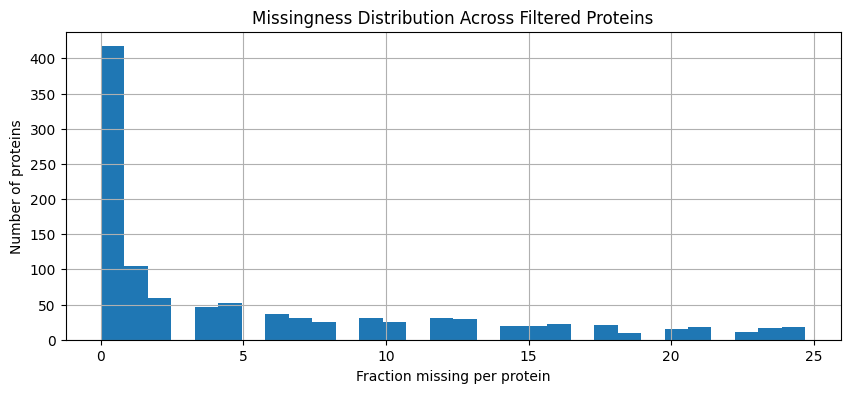

In [174]:
protein_missingness_threshold = 25 

protein_missingness = protein_data.iloc[:, 1:].isnull().mean(axis=1) * 100

proteins_to_keep = protein_missingness[protein_missingness <= protein_missingness_threshold].index

filtered_protein_data = protein_data.iloc[proteins_to_keep, :]

filtered_protein_missingness = filtered_protein_data.iloc[:, 1:].isnull().mean(axis=1) * 100


filtered_protein_missingness_df = pd.DataFrame({
    'protein': filtered_protein_data.iloc[:, 0], 
    'missingness_percentage': filtered_protein_missingness
})

filtered_protein_missingness_df.to_csv('filtered_protein_missingness.csv', index=False)

print("\nTop 5 filtered proteins with most missing data:")
print(filtered_protein_missingness_df.sort_values(by='missingness_percentage', ascending=False).head())

plt.figure(figsize=(10, 4))
filtered_protein_missingness.hist(bins=30)
plt.title("Missingness Distribution Across Filtered Proteins")
plt.xlabel("Fraction missing per protein")
plt.ylabel("Number of proteins")
plt.show()

In [213]:
patient_missingness = filtered_by_proteins.iloc[:,1:].isnull().mean(axis=0)

target_keep_patients = 85
patient_threshold = np.percentile(patient_missingness, 100*(target_keep_patients/len(expression_matrix.columns)))

removed_patients = patient_missingness[patient_missingness > patient_threshold].index.tolist()
good_patients = patient_missingness[patient_missingness <= patient_threshold].index

final_expression_PR80PT00 = filtered_by_proteins.loc[:, ['Genes'] + good_patients.tolist()]

print(f"\n=== PATIENT FILTERING ===")
print(f"Used adaptive threshold: {patient_threshold:.1%} missing")
print(f"Removed {len(removed_patients)} patients: {removed_patients}")
print(f"Retained {len(good_patients)} patients")
final_expression_PR80PT00.to_csv('final_expression_PR80PT00.csv', index=False)


=== PATIENT FILTERING ===
Used adaptive threshold: 35.6% missing
Removed 0 patients: []
Retained 85 patients


In [192]:
patient_missingness = filtered_by_proteins.iloc[:, 1:].isnull().mean(axis=0) * 100

missingness_sample_df = pd.DataFrame({
    'sample': filtered_by_proteins.columns[1:], 
    'missingness_percentage': patient_missingness
})

missingness_sample_df.to_csv('sample_missingness_PR80.csv', index=False)

print("\nTop 5 samples with most missing data:")
print(missingness_sample_df.sort_values(by='missingness_percentage', ascending=False).head())



Top 5 samples with most missing data:
              sample  missingness_percentage
Sample 46  Sample 46               35.575943
Sample 52  Sample 52               29.153925
Sample 57  Sample 57               24.057085
Sample 90  Sample 90               23.445464
Sample 31  Sample 31               21.202854


In [ ]:
print(final_expression_PRPT.shape)

Check per cohort missingness

In [97]:
protein_data.head(10)

,Genes,Sample 1,Sample 2,Sample 3,Sample 4,Sample 5,Sample 60,Sample 6,Sample 7,Sample 8,...,Sample 37,Sample 79,Sample 61,Sample 66,Sample 31,Sample 52,Sample 76,Sample 83,Sample 87,Sample 90
0,MAPK1,7.802514,10.202104,9.953741,9.398615,8.750083,8.618377,8.981996,10.487751,9.487393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F8A1,NaN,7.770043,8.416663,7.179153,9.049793,NaN,7.979900,8.314826,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SUGT1,NaN,9.787278,7.674279,8.868290,7.480898,NaN,8.244653,9.618045,8.504347,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RBX1,NaN,9.263706,9.463213,8.738964,9.040746,8.210388,8.473520,9.384979,9.081190,...,8.283936,NaN,NaN,8.282974,NaN,NaN,NaN,NaN,NaN,NaN
4,PEPD,NaN,8.238970,7.633213,8.197812,7.967809,7.550712,7.958359,8.622801,7.632371,...,6.532624,5.856336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.132104
5,EEF1G,8.658194,10.967775,12.913032,10.452812,12.098784,10.537974,11.993300,11.524775,12.139093,...,8.728512,8.298091,7.584901,8.766936,6.238077,8.087222,8.059769,7.485998,9.137424,6.618598
6,VTA1,NaN,8.468172,9.322748,8.312569,10.084401,8.747556,8.982010,8.984585,8.922803,...,NaN,NaN,6.496951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,LSM5,6.610382,8.416187,10.032527,7.744039,11.051090,8.795145,9.023262,9.307338,8.707675,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.615173,NaN,NaN
8,PFDN1,NaN,9.448796,10.136892,8.829931,10.266574,8.939640,9.386931,10.379843,9.367222,...,8.120749,NaN,NaN,7.816145,NaN,NaN,NaN,7.409969,8.011096,NaN
9,PSMD5,7.072156,8.612993,9.984705,8.199515,10.078999,9.307480,9.699084,9.317669,9.361386,...,7.579031,6.927939,7.555246,8.053018,6.838675,NaN,6.493202,7.054977,7.514430,6.507881


In [134]:
import pandas as pd
import re

sample_map = pd.read_csv("/home/vsayyalasomayajula/Documents/Proteomics/PlasmaAAA/Proteomics sample labels.csv")

sample_map["sample_id"] = sample_map["Sample_index"].str.extract(r'(\d+)').astype(int)
sample_map = sample_map.set_index("sample_id") 
sample_labels = sample_map["TrueLabel"]  

expression_df = protein_data.copy()

expression_df.columns = [expression_df.columns[0]] + expression_df.columns[1:].str.extract(r'(\d+)')[0].astype(int).tolist()
print(expression_df.shape)
genes_col_df = expression_df.iloc[:, [0]]
expression_df = expression_df.loc[:, expression_df.columns.isin(sample_labels.index)]
print(expression_df.shape)
sample_labels = sample_labels.loc[expression_df.columns]


(1766, 86)
(1766, 85)


In [146]:
expression_df.head()
genes_col_df.head()
genes_col_df.to_csv('genes_col_df.csv', index=True)

In [ ]:
protein_data.shape

In [99]:
import pandas as pd
expr_t = expression_df.T

expr_t["cohort"] = sample_labels

missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.drop(columns="cohort").isna().mean())

missing_by_cohort = missing_by_cohort.T


/tmp/ipykernel_7418/3430745195.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_cohort = expr_t.groupby("cohort").apply(lambda df: df.drop(columns="cohort").isna().mean())


In [100]:
import pandas as pd 
expression_data = expression_df.copy()

cohorts = expression_data.columns.map(sample_labels)

expression_T = expression_data.T
expression_T['cohort'] = cohorts.values

missingness_per_cohort = (
    expression_T
    .groupby('cohort')
    .apply(lambda df: df.isna().sum().sum() / df.drop(columns='cohort').size * 100)
)

print("Missingness percentage per cohort:")
print(missingness_per_cohort)


Missingness percentage per cohort:
cohort
AAA        26.327224
AAA-DM     19.408941
Control    29.596074
dtype: float64


/tmp/ipykernel_7418/1812452808.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.isna().sum().sum() / df.drop(columns='cohort').size * 100)


(1766,)


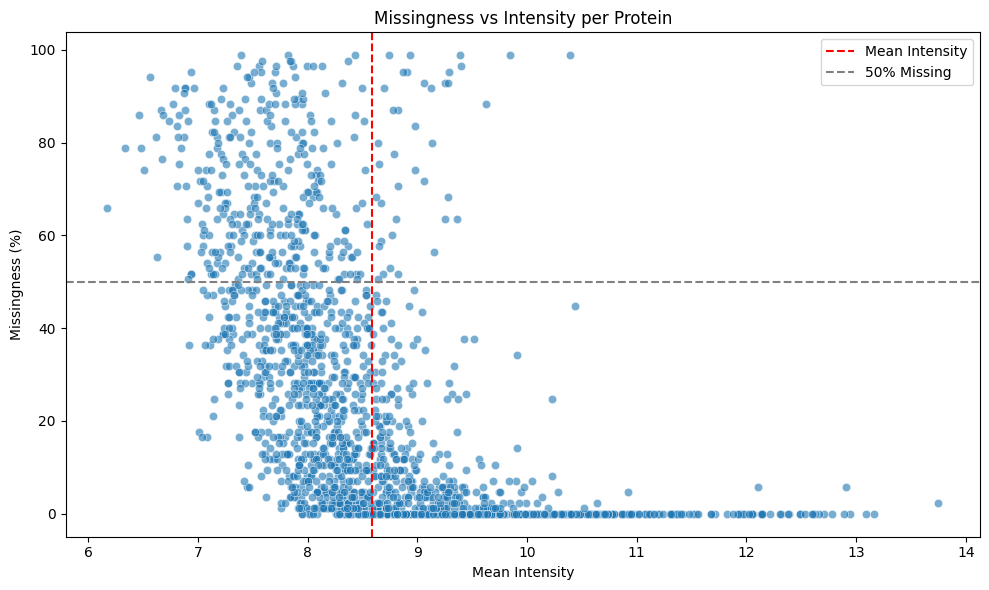

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute mean intensity and missing % per protein
mean_intensity = expression_data.mean(axis=1)
missing_percent = expression_data.isna().sum(axis=1) / expression_data.shape[1] * 100
print(mean_intensity.shape)
# Combine into a DataFrame for plotting
diagnostic_df = pd.DataFrame({
    'mean_intensity': mean_intensity,
    'missing_percent': missing_percent
})

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df, x='mean_intensity', y='missing_percent', alpha=0.6)

# Add vertical line: mean of mean intensities
plt.axvline(diagnostic_df['mean_intensity'].mean(), color='red', linestyle='--', label='Mean Intensity')

# Add horizontal line at 50% missingness
plt.axhline(50, color='gray', linestyle='--', label='50% Missing')

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity per Protein')
plt.legend()
plt.tight_layout()
plt.show()


In [116]:
print(sample_map.columns)

Index(['Sample_index', 'LabelZ', 'TrueLabel', 'Label'], dtype='object')


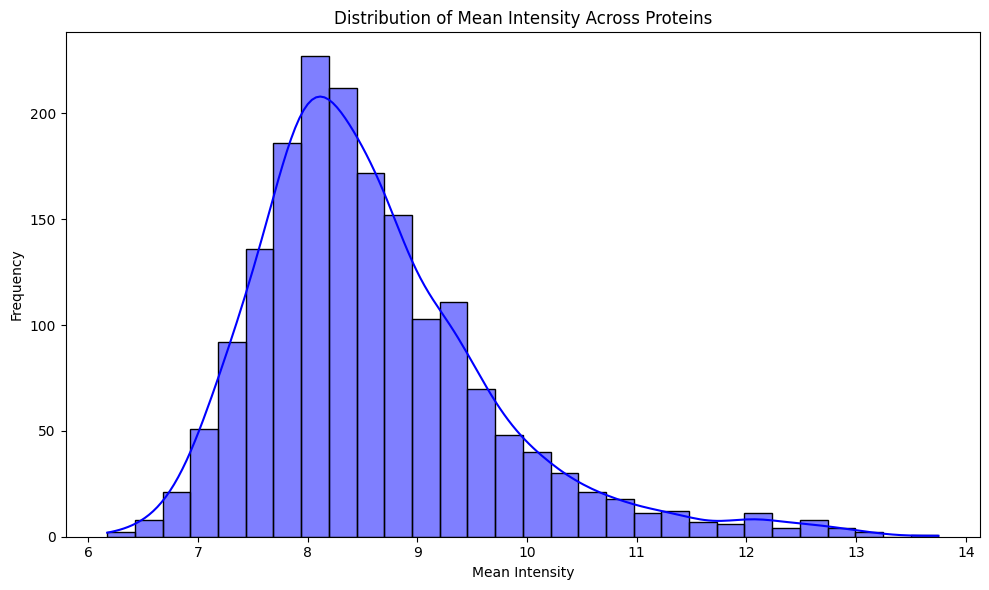

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the histogram of mean intensity values
plt.figure(figsize=(10, 6))
sns.histplot(mean_intensity, kde=True, color='blue', bins=30)

# Add labels and title
plt.title('Distribution of Mean Intensity Across Proteins')
plt.xlabel('Mean Intensity')
plt.ylabel('Frequency')

# Show the plot
plt.tight_layout()
plt.show()


Per Cohort

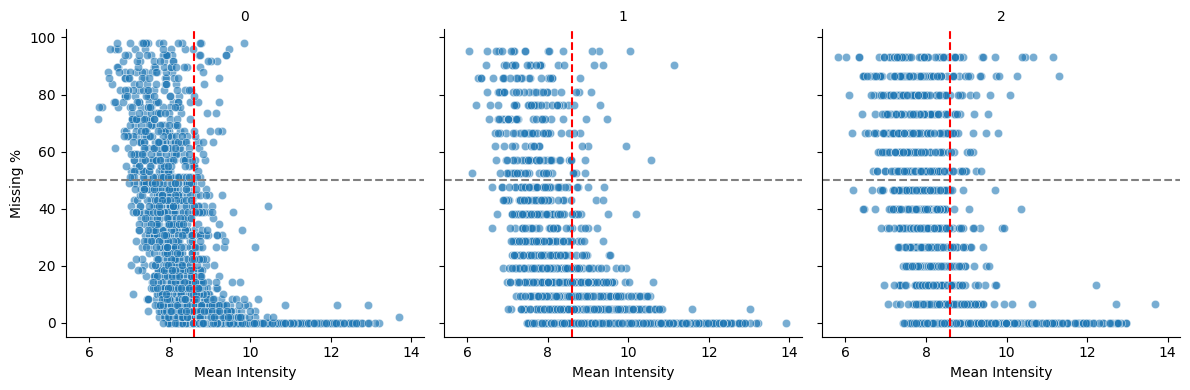

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

expression_T = expression_data.T.copy().reset_index(drop=True)

expression_T['cohort'] = sample_labels.values

long_df = expression_T.melt(id_vars='cohort', var_name='protein', value_name='intensity')

summary_df = (
    long_df
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

g = sns.FacetGrid(
    summary_df,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(50, color='gray', linestyle='--')
    ax.axvline(summary_df['mean_intensity'].mean(), color='red', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# Convert TrueLabel to integer type
sample_map['TrueLabel'] = sample_map['TrueLabel'].astype(int)

diagnostic_df['cohort'] = diagnostic_df.index.map(sample_map['TrueLabel'])

if 'cohort' not in diagnostic_df.columns:
    raise KeyError("The 'cohort' column does not exist in diagnostic_df. Please check the mapping process.")

cohort_labels = diagnostic_df['cohort'].unique()

contingency_table = []

for cohort in cohort_labels:
    cohort_data = diagnostic_df[diagnostic_df['cohort'] == cohort]
    missing_data = cohort_data['missing_percent'] > 0
    missing_count = missing_data.sum()
    non_missing_count = len(missing_data) - missing_count
non_
    if missing_count > 0 or non_missing_count > 0:
        contingency_table.append([missing_count, non_missing_count])

contingency_table = np.array(contingency_table)

print("Contingency Table (filtered):")
print(contingency_table)

if contingency_table.shape[0] > 1: 
    g_stat, p_value, _, _ = chi2_contingency(contingency_table)
    print("G-test statistic:", g_stat)
    print("p-value:", p_value)

    if p_value < 0.05:
        print("The missingness is significantly associated with the cohort (reject null hypothesis).")
    else:
        print("The missingness is not significantly associated with the cohort (fail to reject null hypothesis).")
else:
    print("The contingency table does not have enough data to perform the test.")

Contingency Table (filtered):
[[34 15]
 [12  9]
 [ 9  6]]
G-test statistic: 1.1417439703153982
p-value: 0.5650325238491394
The missingness is not significantly associated with the cohort (fail to reject null hypothesis).


In [138]:
expression_T.head()

,0,1,2,3,4,5,6,7,8,9,...,1757,1758,1759,1760,1761,1762,1763,1764,1765,cohort
0,7.802514,NaN,NaN,NaN,NaN,8.658194,NaN,6.610382,NaN,7.072156,...,NaN,NaN,NaN,6.135507,NaN,NaN,NaN,7.421572,NaN,0
1,10.202104,7.770043,9.787278,9.263706,8.238970,10.967775,8.468172,8.416187,9.448796,8.612993,...,8.394399,7.552727,NaN,9.291334,7.479246,8.895341,NaN,8.248558,7.425526,1
2,9.953741,8.416663,7.674279,9.463213,7.633213,12.913032,9.322748,10.032527,10.136892,9.984705,...,8.236023,8.400126,8.945568,10.415617,7.536879,10.006287,NaN,10.250066,7.863907,0
3,9.398615,7.179153,8.868290,8.738964,8.197812,10.452812,8.312569,7.744039,8.829931,8.199515,...,7.055214,7.194962,NaN,8.896279,7.322532,8.457447,NaN,7.006929,7.215389,0
4,8.750083,9.049793,7.480898,9.040746,7.967809,12.098784,10.084401,11.051090,10.266574,10.078999,...,7.667442,8.050964,10.323881,10.460908,7.949179,9.860862,NaN,10.359087,7.731895,0


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

expression_T['cohort'] = expression_T['cohort'].astype(int)  

long_df = expression_T.melt(id_vars='cohort', var_name='protein', value_name='intensity')

g_test_results = []


for idx, protein in enumerate(long_df['protein'].unique()):

    protein_data = long_df[long_df['protein'] == protein]
    
    contingency_table = pd.DataFrame(0, index=[0, 1], columns=np.unique(protein_data['cohort'])) 
    
    for cohort in np.unique(protein_data['cohort']):
        cohort_data = protein_data[protein_data['cohort'] == cohort]
        missing_data = cohort_data['intensity'].isna().sum()  # Count missing values
        non_missing_data = len(cohort_data) - missing_data  # Count non-missing values
        
        contingency_table.loc[0, cohort] = non_missing_data  # Non-missing count (0)
        contingency_table.loc[1, cohort] = missing_data  # Missing count (1)
    
    print(f"Contingency Table for Protein {protein} (Index {idx}):")
    print(contingency_table)
    
    if np.any(contingency_table.loc[0] == 0) or np.any(contingency_table.loc[1] == 0):  # If 100% present or 100% missing
        print(f"Skipping G-test for protein {protein} (Index {idx}) due to 100% present or 100% missing values in a cohort.")
        # Add a record for proteins with no missing data
        g_test_results.append({
            'protein_index': idx,
            'protein': protein,
            'g_statistic': None,
            'p_value': None,
            'comment': 'All present or all missing'
        })
        continue

    g_stat, p_value, _, _ = chi2_contingency(contingency_table)
    
    g_test_results.append({
        'protein_index': idx,
        'protein': protein,
        'g_statistic': g_stat,
        'p_value': p_value,
        'comment': 'Test performed'
    })

g_test_df = pd.DataFrame(g_test_results)

g_test_df.to_csv('g_test_results_per_protein.csv', index=False)

print(g_test_df)

Contingency Table for Protein 0 (Index 0):
    0   1   2
0  38  18  12
1  11   3   3
Contingency Table for Protein 1 (Index 1):
    0   1  2
0  19  14  7
1  30   7  8
Contingency Table for Protein 2 (Index 2):
    0   1  2
0  30  18  6
1  19   3  9
Contingency Table for Protein 3 (Index 3):
    0   1   2
0  30  19  10
1  19   2   5
Contingency Table for Protein 4 (Index 4):
    0   1  2
0  34  20  9
1  15   1  6
Contingency Table for Protein 5 (Index 5):
    0   1   2
0  49  21  15
1   0   0   0
Skipping G-test for protein 5 (Index 5) due to 100% present or 100% missing values in a cohort.
Contingency Table for Protein 6 (Index 6):
    0   1   2
0  37  18  10
1  12   3   5
Contingency Table for Protein 7 (Index 7):
    0   1   2
0  37  20  10
1  12   1   5
Contingency Table for Protein 8 (Index 8):
    0   1   2
0  38  20  13
1  11   1   2
Contingency Table for Protein 9 (Index 9):
    0   1   2
0  46  21  15
1   3   0   0
Skipping G-test for protein 9 (Index 9) due to 100% present or 

In [142]:
import pandas as pd
import numpy as np

contingency_tables = []

for protein in long_df['protein'].unique():
    protein_data = long_df[long_df['protein'] == protein]
    
    contingency_table = pd.DataFrame(0, index=[0, 1], columns=np.unique(protein_data['cohort']))  # 0: non-missing, 1: missing
    
    for cohort in np.unique(protein_data['cohort']):
        cohort_data = protein_data[protein_data['cohort'] == cohort]
        missing_data = cohort_data['intensity'].isna().sum() 
        non_missing_data = len(cohort_data) - missing_data  
        
        contingency_table.loc[0, cohort] = non_missing_data 
        contingency_table.loc[1, cohort] = missing_data 
    
    contingency_tables.append(contingency_table)

multi_index = pd.MultiIndex.from_product([long_df['protein'].unique(), [0, 1], np.unique(long_df['cohort'])],
                                         names=["protein", "missing_status", "cohort"])


contingency_df = pd.DataFrame(np.concatenate([table.values.flatten() for table in contingency_tables]),
                              index=multi_index,
                              columns=["count"])

contingency_df = contingency_df.unstack(level="cohort")

print(contingency_df.head(10))

contingency_df.to_csv('contingency_tables_per_protein.csv')

                       count        
cohort                     0   1   2
protein missing_status              
0       0                 38  18  12
        1                 11   3   3
1       0                 19  14   7
        1                 30   7   8
2       0                 30  18   6
        1                 19   3   9
3       0                 30  19  10
        1                 19   2   5
4       0                 34  20   9
        1                 15   1   6


In [143]:

protein_name = 0  

protein_contingency_table = contingency_df.xs(protein_name, level="protein")

print(protein_contingency_table)


               count        
cohort             0   1   2
missing_status              
0                 38  18  12
1                 11   3   3


Proteins with significant missingness association to cohorts:
      protein_index  protein  g_statistic   p_value         comment
2                 2        2     8.157414  0.016929  Test performed
4                 4        4     7.013036  0.030001  Test performed
69               69       69     6.304373  0.042759  Test performed
77               77       77     6.425932  0.040237  Test performed
85               85       85     6.317990  0.042468  Test performed
...             ...      ...          ...       ...             ...
1734           1734     1734     6.279971  0.043283  Test performed
1743           1743     1743     6.225888  0.044470  Test performed
1752           1752     1752     6.753741  0.034154  Test performed
1761           1761     1761     7.037717  0.029633  Test performed
1764           1764     1764     7.743718  0.020820  Test performed

[170 rows x 5 columns]


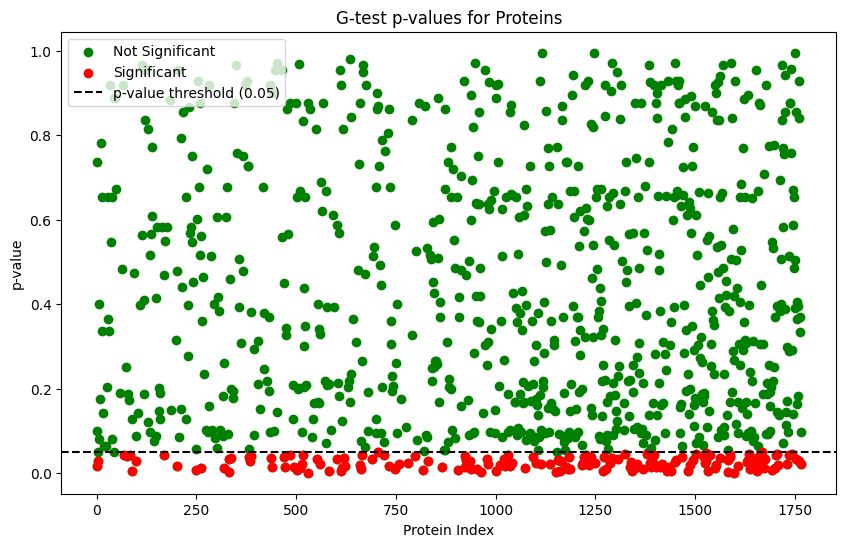

In [ ]:

significance_threshold = 0.05

significant_proteins = g_test_df[g_test_df['p_value'] < significance_threshold]
# Adding a new column 'significance' based on the p-value threshold
g_test_df['significance'] = g_test_df['p_value'].apply(lambda x: 2 if x < significance_threshold else 1)

# Save to CSV
g_test_df[['protein', 'significance']].to_csv('proteins_significance.csv', index=False)

# Print the DataFrame to see the result
print(g_test_df[['protein', 'significance']])
print("Proteins with significant missingness association to cohorts:")
print(significant_proteins)

significant_proteins.to_csv('significant_proteins.csv', index=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(g_test_df['protein'], g_test_df['p_value'], color='green', label='Not Significant')
plt.scatter(significant_proteins['protein'], significant_proteins['p_value'], color='red', label='Significant')

plt.axhline(y=0.05, color='black', linestyle='--', label="p-value threshold (0.05)")

plt.xlabel('Protein Index')
plt.ylabel('p-value')
plt.title('G-test p-values for Proteins')
plt.legend()
plt.show()


In [147]:
# Adding a new column 'significance' based on the p-value threshold
g_test_df['significance'] = g_test_df['p_value'].apply(lambda x: 2 if x < significance_threshold else 1)

# Save to CSV
g_test_df[['protein', 'significance']].to_csv('proteins_significance.csv', index=False)

# Print the DataFrame to see the result
print(g_test_df[['protein', 'significance']])

      protein  significance
0           0             1
1           1             1
2           2             2
3           3             1
4           4             2
...       ...           ...
1761     1761             2
1762     1762             1
1763     1763             1
1764     1764             2
1765     1765             1

[1766 rows x 2 columns]


In [ ]:
genes_col_df = pd.read_csv('genes_col_df.csv', index_col=0)
g_test_df_p = pd.read_csv('proteins_significance.csv')

merged_df = pd.merge(genes_col_df, g_test_df_p, left_on='Index', right_on='protein', how='left')

merged_df.to_csv('merged_g_test_df.csv', index=False)

print(merged_df.head())

   Genes  protein  significance
0  MAPK1        0             1
1   F8A1        1             1
2  SUGT1        2             2
3   RBX1        3             1
4   PEPD        4             2


In [155]:
non_significant_proteins = g_test_df[g_test_df['significance'] == 1]['protein']
significant_proteins = g_test_df[g_test_df['significance'] == 2]['protein']

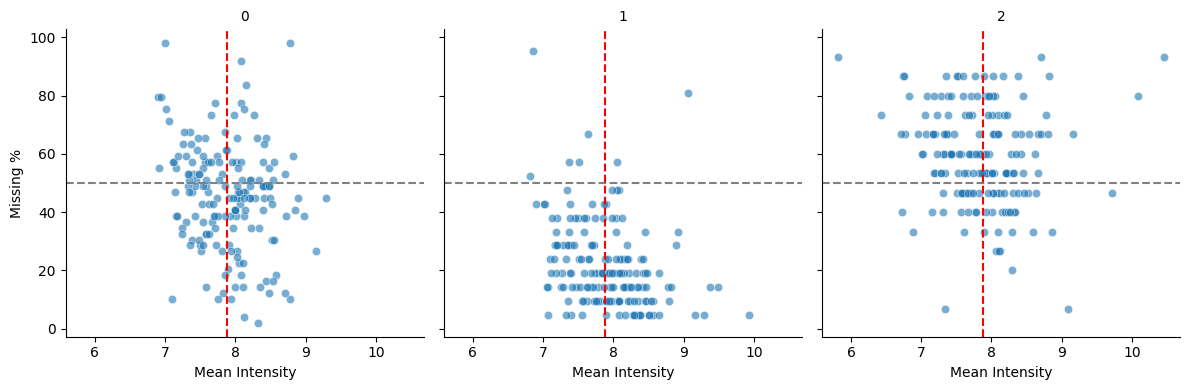

In [ ]:
# Filter to only include non-significant proteins
long_df_non_sig = long_df[long_df['protein'].isin(significant_proteins)]

summary_df_non_sig = (
    long_df_non_sig
    .groupby(['protein', 'cohort'])
    .agg(
        mean_intensity=('intensity', 'mean'),
        missing_percent=('intensity', lambda x: x.isna().mean() * 100)
    )
    .reset_index()
)

g = sns.FacetGrid(
    summary_df_non_sig,
    col="cohort",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='mean_intensity',
    y='missing_percent',
    alpha=0.6
)

for ax in g.axes.flat:
    ax.axhline(50, color='gray', linestyle='--')
    ax.axvline(summary_df_non_sig['mean_intensity'].mean(), color='red', linestyle='--')

g.set_axis_labels("Mean Intensity", "Missing %")
g.set_titles(col_template="{col_name}")

plt.tight_layout()
plt.show()


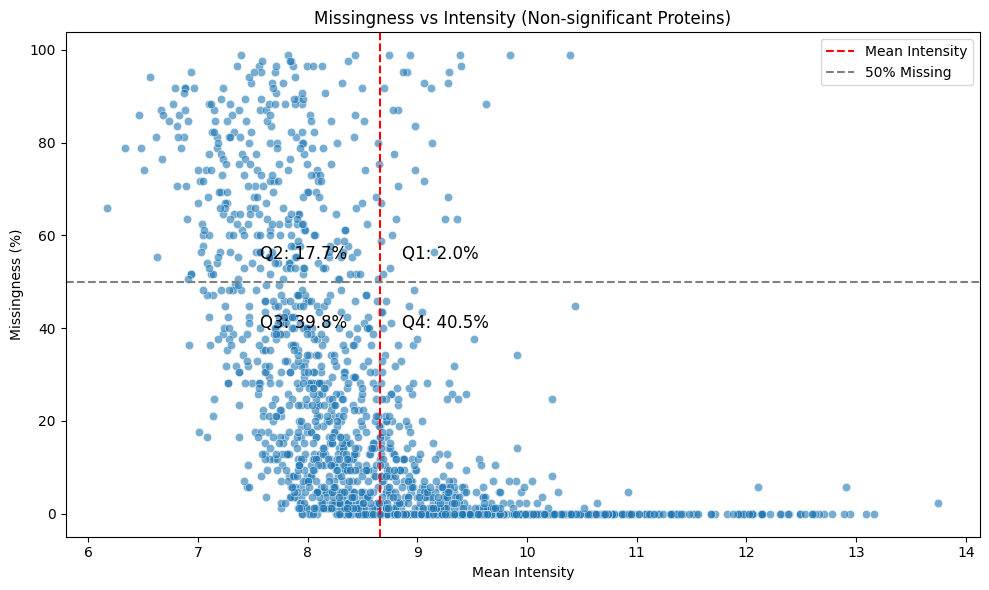

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diagnostic_df_non_sig, x='mean_intensity', y='missing_percent', alpha=0.6)

plt.axvline(mean_intensity_val, color='red', linestyle='--', label='Mean Intensity')
plt.axhline(missing_threshold, color='gray', linestyle='--', label='50% Missing')

# Annotate the extreme corners of each quadrant
plt.text(mean_intensity_val + 0.2, missing_threshold + 5, f'Q1: {perc_q1:.1f}%', fontsize=12)  # Top-right
plt.text(mean_intensity_val - 0.3, missing_threshold + 5, f'Q2: {perc_q2:.1f}%', fontsize=12, ha='right')  # Top-left
plt.text(mean_intensity_val - 0.3, missing_threshold - 10, f'Q3: {perc_q3:.1f}%', fontsize=12, ha='right')  # Bottom-left
plt.text(mean_intensity_val + 0.2, missing_threshold - 10, f'Q4: {perc_q4:.1f}%', fontsize=12)  # Bottom-right

plt.xlabel('Mean Intensity')
plt.ylabel('Missingness (%)')
plt.title('Missingness vs Intensity (Non-significant Proteins)')
plt.legend()
plt.tight_layout()
plt.show()


Lets check missingness on the filtered dataset 

Whole-Dataset level

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import chi2

def little_mcar_test(data):
    # Convert data to numeric and create a mask for missingness
    data = data.apply(pd.to_numeric, errors='coerce')
    missing_mask = data.isnull().astype(int)

    # Calculate means and covariance matrices for complete and incomplete cases
    complete_data = data.dropna()
    incomplete_data = data[~data.index.isin(complete_data.index)]

    n_complete = len(complete_data)
    n_incomplete = len(incomplete_data)

    mean_complete = complete_data.mean()
    mean_incomplete = incomplete_data.mean()

    # Covariance calculation
    cov_complete = complete_data.cov()
    cov_incomplete = incomplete_data.cov()

    # Calculate test statistic
    mean_diff = (mean_incomplete - mean_complete).values.reshape(-1, 1)
    pooled_cov = (n_complete * cov_complete + n_incomplete * cov_incomplete) / (n_complete + n_incomplete)

    test_stat = n_complete * n_incomplete / (n_complete + n_incomplete) * mean_diff.T @ np.linalg.inv(pooled_cov) @ mean_diff
    test_stat = test_stat[0, 0]
    
    # Degrees of freedom
    df = data.shape[1]

    # Calculate p-value
    p_value = 1 - chi2.cdf(test_stat, df)

    print(f"Little's MCAR Test Statistic: {test_stat}")
    print(f"p-value: {p_value}")

    if p_value < 0.05:
        print("MCAR hypothesis rejected. Data may be MAR or MNAR.")
        print("P-value:", np.format_float_scientific(p_value, precision=10))
    else:
        print("MCAR hypothesis not rejected. Data may be MCAR.")
        print("P-value:", np.format_float_scientific(p_value, precision=10))

# Example usage
little_mcar_test(final_expression.iloc[:, 1:])


In [ ]:
missing_percentage = final_expression.isnull().mean().mean() * 100
print(f"Overall Missingness: {missing_percentage:.2f}%")

Check for MAR

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(final_expression.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Data Heatmap")
plt.show()
#
correlation = final_expression.iloc[:, 1:].mean(axis=1).corr(
    final_expression.iloc[:, 1:].isnull().mean(axis=1)
)
print(f"Abundance-Missingness Correlation: {correlation:.3f}")


In [ ]:
# Create a missingness matrix
missingness_matrix = final_expression.iloc[:, 1:].isnull().astype(int)

# Calculate the correlation of missingness between proteins and patients
correlation_matrix = missingness_matrix.T.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt='.2f')
plt.title("Correlation of Missingness Between Proteins/Patients")
plt.show()

In [ ]:
import missingno as msno
msno.matrix(final_expression)
plt.show()

MCAR test with dimensionality reduction (random sampling)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# Assuming your DataFrame looks like:
# Index | Gene_Symbol | Patient1 | Patient2 | ... | Patient75
df = final_expression
print(df.head(5))

# Set gene symbols as index, then transpose
df_transposed = df.set_index("Genes").T  # Now: Rows=Patients, Columns=Proteins

def subset_and_test(df, n_iterations=10, subset_size=50, alpha=0.05, min_samples=5):
    violations = []
    for iteration in range(n_iterations):
        proteins_subset = np.random.choice(df.columns, size=subset_size, replace=False)
        df_subset = df[proteins_subset]
        missing_indicator = df_subset.isnull()
        
        for protein in df_subset.columns:
            missing_count = missing_indicator[protein].sum()
            if missing_count == 0 or missing_count == len(df_subset):
                continue  # Skip if no variance in missingness
            
            # Ensure enough samples in both groups
            group_observed = df_subset.loc[~missing_indicator[protein]]
            group_missing = df_subset.loc[missing_indicator[protein]]
            
            if len(group_observed) < min_samples or len(group_missing) < min_samples:
                continue  # Skip if either group is too small
            
            for other_protein in df_subset.columns:
                if other_protein == protein:
                    continue
                
                # Drop NaNs in the other protein's values
                observed_values = group_observed[other_protein].dropna()
                missing_values = group_missing[other_protein].dropna()
                
                if len(observed_values) < min_samples or len(missing_values) < min_samples:
                    continue
                
                # Use Mann-Whitney U test (more robust than t-test)
                from scipy.stats import mannwhitneyu
                try:
                    stat, p_val = mannwhitneyu(observed_values, missing_values)
                    if p_val < alpha:
                        violations.append({
                            'Protein': protein,
                            'Related_Protein': other_protein,
                            'p_value': p_val,
                            'Iteration': iteration + 1
                        })
                except ValueError:
                    continue
    
    return pd.DataFrame(violations)

# Usage example (after transposing your data)
violations_df = subset_and_test(df_transposed)
print("Protein pairs violating MCAR:")
print(violations_df.sort_values('p_value'))

We can reject MCAR assumption now

Check if we can also reject MNAR assumptio and accept MAR - then we can use multiple imputation techniques

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your data is loaded as df (rows=proteins, columns=patients)
# Column 0 contains gene symbols - set it as index if needed
df = df.set_index(df.columns[0]) if df.columns[0] == 'Genes' else df

# --------------------------------------
# STEP 1: Calculate missingness rates
# --------------------------------------
missing_rates = df.isnull().mean(axis=1)  # Protein-wise missingness
high_missing_proteins = missing_rates[missing_rates > 0.1].index  # Focus on proteins with >10% missingness

# --------------------------------------
# STEP 2: Estimate detection threshold
# --------------------------------------
def estimate_detection_threshold(df, high_missing_proteins, percentile=5):
    """Estimate detection threshold using lowest reliable measurements"""
    low_abundances = []
    for protein in high_missing_proteins:
        observed_values = df.loc[protein].dropna()
        if len(observed_values) > 0:
            low_abundances.append(np.percentile(observed_values, percentile))
    return np.median(low_abundances)

detection_threshold = estimate_detection_threshold(df, high_missing_proteins)
print(f"Estimated detection threshold (median {5}th percentile of high-missing proteins): {detection_threshold:.2f}")

# --------------------------------------
# STEP 3: Visualization (Validation)
# --------------------------------------
def plot_threshold_validation(df, protein, threshold):
    """Plot abundance distribution with threshold line"""
    observed = df.loc[protein].dropna()
    
    plt.figure(figsize=(10, 5))
    sns.histplot(observed, bins=30, kde=True, stat='density')
    plt.axvline(threshold, color='red', linestyle='--', 
                label=f'Estimated threshold: {threshold:.2f}')
    
    # Add shaded area for likely missing values
    plt.axvspan(observed.min() - 1, threshold, alpha=0.2, color='red')
    
    plt.title(f'Abundance Distribution for {protein}\n(Missing rate: {missing_rates[protein]:.1%})')
    plt.xlabel('Expression Level')
    plt.legend()
    plt.show()

# Plot for top 3 high-missing proteins
for protein in high_missing_proteins[:3]:
    plot_threshold_validation(df, protein, detection_threshold)

# --------------------------------------
# STEP 4: System-wide missingness analysis
# --------------------------------------
plt.figure(figsize=(10, 6))
median_abundances = df.median(axis=1)
sns.scatterplot(x=median_abundances, y=missing_rates, alpha=0.6)
plt.axvline(detection_threshold, color='red', linestyle='--', 
            label=f'Detection threshold: {detection_threshold:.2f}')

# Annotate proteins with highest missingness
for protein in missing_rates.nlargest(5).index:
    plt.annotate(protein, (median_abundances[protein], missing_rates[protein]),
                 textcoords="offset points", xytext=(0,5), ha='center')

plt.xlabel('Median Protein Abundance (log2)')
plt.ylabel('Missing Rate')
plt.title('Missingness vs. Abundance (System-wide)')
plt.legend()
plt.show()

# --------------------------------------
# STEP 5: MNAR Assessment
# --------------------------------------
def evaluate_mnar(df, threshold):
    """Quantify how many missing values fall below threshold"""
    missing_below_threshold = 0
    total_missing = df.isnull().sum().sum()
    
    for protein in df.index:
        # Find patients where this protein is missing
        missing_patients = df.columns[df.loc[protein].isnull()]
        
        # For these patients, check other protein abundances
        for patient in missing_patients:
            other_abundances = df[patient].dropna()
            if len(other_abundances) > 0 and other_abundances.median() < threshold:
                missing_below_threshold += 1
                
    return missing_below_threshold / total_missing

mnar_ratio = evaluate_mnar(df, detection_threshold)
print(f"Percentage of missing values that occur when median abundance is below threshold: {mnar_ratio:.1%}")

# --------------------------------------
# Interpretation Guide
# --------------------------------------
print("\nInterpretation Guide:")
print(f"- If most missing values occur below {detection_threshold:.2f} (high ratio above), MNAR is likely")
print("- If missingness is spread evenly across abundances, consider MAR")
print("- Validate with domain knowledge about your detection technology")

In [ ]:
import pandas as pd
import numpy as np

# Assuming:
# - df: Your DataFrame (proteins=rows, patients=columns)
# - detection_threshold: Estimated earlier (e.g., 1.85)

# Calculate key metrics for each protein
protein_stats = pd.DataFrame({
    'Median_Abundance': df.median(axis=1),
    'Missingness_Rate': df.isnull().mean(axis=1),
    'Below_Threshold': df.median(axis=1) < detection_threshold
})

# Sort by missingness (descending) and median abundance (ascending)
protein_stats = protein_stats.sort_values(
    by=['Missingness_Rate', 'Median_Abundance'],
    ascending=[False, True]
)

# Add gene symbols if needed (assuming they're in the index)
protein_stats['Gene_Symbol'] = protein_stats.index

# Filter proteins below threshold with high missingness
high_missing_candidates = protein_stats[
    (protein_stats['Below_Threshold']) & 
    (protein_stats['Missingness_Rate'] > 0.00005)  # Adjust threshold as needed
]

print(f"\n{'='*50}\nProteins Below Detection Threshold (High Missingness)\n{'='*50}")
print(high_missing_candidates[['Gene_Symbol', 'Median_Abundance', 'Missingness_Rate']])

# Save to CSV for review
high_missing_candidates.to_csv("proteins_below_threshold.csv")

# Visualize the worst offenders
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=protein_stats,
    x='Median_Abundance',
    y='Missingness_Rate',
    hue='Below_Threshold',
    palette={True: 'red', False: 'blue'},
    alpha=0.7
)
plt.axvline(detection_threshold, color='black', linestyle='--', label=f'Detection Threshold ({detection_threshold:.2f})')
plt.title("Protein Missingness vs. Abundance")
plt.xlabel("Median Abundance (log2)")
plt.ylabel("Missingness Rate")
plt.legend(title='Below Threshold?')
plt.show()

Gaussian mixture model - detect global threshold

In [ ]:
from sklearn.mixture import GaussianMixture
all_observed_values = df.values.flatten()  # Convert to 1D array
all_observed_values = all_observed_values[~np.isnan(all_observed_values)]  # Drop NaNs
# Fit GMM to log-transformed abundances (assuming proteomics data)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(np.log1p(all_observed_values).reshape(-1, 1))

# Threshold = intersection point of the two Gaussians
means = gmm.means_.flatten()
stds = np.sqrt(gmm.covariances_.flatten())
intersection = (means[0]*stds[1] + means[1]*stds[0]) / (stds[0] + stds[1])
global_threshold = np.expm1(intersection)  # Reverse log-transform

print(f"Global threshold (GMM-derived): {global_threshold:.2f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten all observed values (non-missing)
all_observed_values = df.values.flatten()
all_observed_values = all_observed_values[~np.isnan(all_observed_values)]

# Plot histogram with threshold
plt.figure(figsize=(10, 6))
sns.histplot(all_observed_values, bins=50, kde=True, stat='density', color='skyblue')

# Add global threshold line (GMM-derived: 5.65)
global_threshold = 5.65
plt.axvline(global_threshold, color='red', linestyle='--', 
            label=f'Global Threshold: {global_threshold:.2f}')

# Highlight the "missingness zone" left of the threshold
plt.axvspan(
    xmin=np.min(all_observed_values) - 1, 
    xmax=global_threshold, 
    alpha=0.2, color='red', 
    label='Potential MNAR Zone'
)

plt.xlabel('Protein Abundance')
plt.ylabel('Density')
plt.title('Dataset-Level Abundance Distribution\n(Red Zone: Potential MNAR Missingness)')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
#
protein_stats = pd.DataFrame({
    'Median_Abundance': df.median(axis=1),
    'Missingness_Rate': df.isnull().mean(axis=1),
    'Below_Threshold': df.median(axis=1) < global_threshold
})

# Sort by missingness (descending) and median abundance (ascending)
protein_stats = protein_stats.sort_values(
    by=['Missingness_Rate', 'Median_Abundance'],
    ascending=[False, True]
)

# Add gene symbols if needed (assuming they're in the index)
protein_stats['Gene_Symbol'] = protein_stats.index

# Filter proteins below threshold with high missingness
high_missing_candidates = protein_stats[
    (protein_stats['Below_Threshold']) & 
    (protein_stats['Missingness_Rate'] > 0.00005)  # Adjust threshold as needed
]
#
# Scatter plot with enhanced visuals
scatter = sns.scatterplot(
    data=protein_stats,
    x='Median_Abundance',
    y='Missingness_Rate',
    hue='Below_Threshold',
    palette={True: 'red', False: 'blue'},
    alpha=0.7,
    s=100,  # Larger dots
    edgecolor='w',  # White borders for clarity
    linewidth=0.5
)

# Highlight the detection threshold
plt.axvline(
    x=global_threshold, 
    color='black', 
    linestyle='--', 
    linewidth=1.5,
    label=f'Detection Threshold ({global_threshold:.2f})'
)

# Annotate high-missingness proteins
for protein in high_missing_candidates.index:
    plt.annotate(
        protein_stats.loc[protein, 'Gene_Symbol'],
        (protein_stats.loc[protein, 'Median_Abundance'], 
        protein_stats.loc[protein, 'Missingness_Rate']),
        textcoords="offset points",
        xytext=(5, 5),
        ha='left',
        fontsize=8,
        color='darkred'
    )

# Emphasize the "MNAR zone" (left of threshold)
plt.axvspan(
    xmin=protein_stats['Median_Abundance'].min() - 1,
    xmax=global_threshold,
    alpha=0.1,
    color='red',
    label='Potential MNAR Zone'
)

plt.xlabel('Median Protein Abundance (log2)')
plt.ylabel('Missingness Rate')
plt.title('Missingness Patterns: MNAR Assessment\n(Red = Below Threshold)')
plt.legend(title='Below Threshold?', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

We can safely reject MNAR hypothesis

Set up imputation methods now on the dataset .. use multiple and compare 

MICE Imputer
useful for non-linear relationships between proteins 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

# =============================================
# 1. Data Preparation (Optimized)
# =============================================

gene_symbols = final_expression.iloc[:, 0].to_numpy()


X = final_expression.iloc[:, 1:].to_numpy().T.astype(np.float32)  # Transpose for MICE

# =============================================
# 2. Optimized MICE Configuration
# =============================================
imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=50,  
        max_depth=10, 
        n_jobs=-1, 
        random_state=42
    ),
    max_iter=20,  
    tol=1e-3, 
    n_nearest_features=25, 
    initial_strategy="median", 
    verbose=2,  
    random_state=42
)

# =============================================
# 3. Perform MICE Imputation
# =============================================
print("Starting optimized MICE imputation...")
X_imputed = imputer.fit_transform(X)

# =============================================
# 4. Memory-Efficient Reconstruction
# =============================================
df_imputed = pd.DataFrame(
    X_imputed.T, 
    columns=final_expression.columns[1:],  
    index=final_expression.index
).astype(np.float32)

df_imputed.insert(0, 'Gene', gene_symbols)  # Reattach gene symbols

# =============================================
# 5. Save & Evaluate
# =============================================
df_imputed.to_csv("imputed_mice_optimized_cpt.csv", index=False)

missing_mask = np.isnan(X)

print(f"MICE completed in {imputer.n_iter_} iterations")


KNN imputer 

In [ ]:
from sklearn.impute import KNNImputer
import numpy as np
import pandas as pd

# Grid search parameters
param_grid = {
    'n_neighbors': [10, 25, 50, 75, 100],
    'weights': ['uniform', 'distance']
}

# Initialize KNN imputer
knn_imputer = KNNImputer()

# Placeholder for stability results
stability_results = []

# Number of runs for stability test
n_runs = 10

for n_neighbors in param_grid['n_neighbors']:
    for weights in param_grid['weights']:
        print(f"Trying n_neighbors = {n_neighbors}, weights = {weights}...")

        # Set up the KNN imputer with the current parameters
        imputer = KNNImputer(n_neighbors=n_neighbors, metric='nan_euclidean', weights=weights)

        # Run the imputation multiple times for stability
        imputed_dfs = []
        for _ in range(n_runs):
            X_imputed = imputer.fit_transform(X)  # Assuming X is your input data

            # Store the imputed result for stability check
            imputed_dfs.append(X_imputed)

        # Calculate the variance across the runs
        imputed_dfs_array = np.array(imputed_dfs)
        variance = np.var(imputed_dfs_array, axis=0)  # Calculate variance across the runs

        # Store the variance and configuration in the results
        stability_results.append({
            'n_neighbors': n_neighbors,
            'weights': weights,
            'variance': np.mean(variance)  # Average variance across all features
        })

# Find the configuration with the minimum variance
best_config = min(stability_results, key=lambda x: x['variance'])

print(f"Best configuration (least variance): {best_config}")

# Apply the best imputer configuration
best_imputer = KNNImputer(n_neighbors=best_config['n_neighbors'], metric='nan_euclidean', 
                          weights=best_config['weights'])

X_knn_optimized = best_imputer.fit_transform(X)

# Reconstruct DataFrame
df_knn_optimized = pd.DataFrame(X_knn_optimized.T, columns=final_expression.columns[1:], index=final_expression.index)
df_knn_optimized.insert(0, 'Gene', gene_symbols)

# Save the optimized result
df_knn_optimized.to_csv("imputed_knn_optimized_stability.csv", index=False)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

gene_symbols = final_expression.iloc[:, 0].copy()
X = final_expression.iloc[:, 1:].T.astype(np.float32).to_numpy()
missing_mask = np.isnan(X)
print(X.shape)
print(missing_mask.shape)

imputer = IterativeImputer(
    
    max_iter=10,                 
    tol=1e-3,                    
    sample_posterior=True,       
    

    n_nearest_features=50,      
    skip_complete=True,          
    min_value=0,                 
    verbose=2,                   
    
    # Hardware Acceleration
    random_state=42
)

print("Starting optimized MICE imputation...")
X_imputed = imputer.fit_transform(X)
print(X_imputed.shape)
X_flat = X.flatten()
X_imputed_flat = X_imputed.flatten()

X_missing = X_flat[missing_mask.flatten()]  
X_imputed_missing = X_imputed_flat[missing_mask.flatten()]  

# Now X_missing and X_imputed_missing are 1D arrays with the same length
print(f"X_missing shape: {X_missing.shape}")
print(f"X_imputed_missing shape: {X_imputed_missing.shape}")
#mse = mean_squared_error(X_missing, X_imputed_missing)

df_imputed = pd.DataFrame(
    X_imputed.T,
    columns=final_expression.columns[1:],
    index=final_expression.index
).astype(np.float32)

df_imputed.insert(0, 'Gene', gene_symbols)
df_imputed.to_csv("imputed_mice_optimized.csv", index=False)

print(f"MICE completed in {imputer.n_iter_} iterations")

HyperImpute Imputation

In [ ]:
from hyperimpute.plugins.imputers import Imputers
from sklearn.datasets import load_iris
from hyperimpute.plugins.imputers import Imputers
from hyperimpute.utils.benchmarks import compare_models

imputers = Imputers()

imputers.list()

In [ ]:
proteins = final_expression.iloc[:, 0] 
X = final_expression.iloc[:, 1:].copy()

X_transposed = X.T.copy()

imputer = Imputers().get("hyperimpute")

X_imputed = imputer.fit_transform(X_transposed)

X_final = X_imputed.T

final_imputed = pd.concat([proteins, pd.DataFrame(X_final, columns=X.columns)], axis=1)

final_imputed.to_csv("imputed_expression.csv", index=False)
print("✅ Imputation complete! Saved as imputed_expression.csv.")

In [ ]:
print(f"Selected imputer: {imputer.name()}") 

In [ ]:
protein_list = final_expression.iloc[:, 0].tolist()

# Save the protein list to a CSV file
protein_list_df = pd.DataFrame(protein_list, columns=["Protein"])
protein_list_df.to_csv("protein_list_PRPT.csv", index=False)